In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

In [2]:
X = np.load("../processed/X_no_norm.npy")
y = np.load("../processed/y_no_norm.npy")

print(X.shape)
print(y.shape)

(4635, 7, 297)
(4635,)


In [3]:
X_flat = X.reshape(len(X), -1)

print(X_flat.shape)

(4635, 2079)


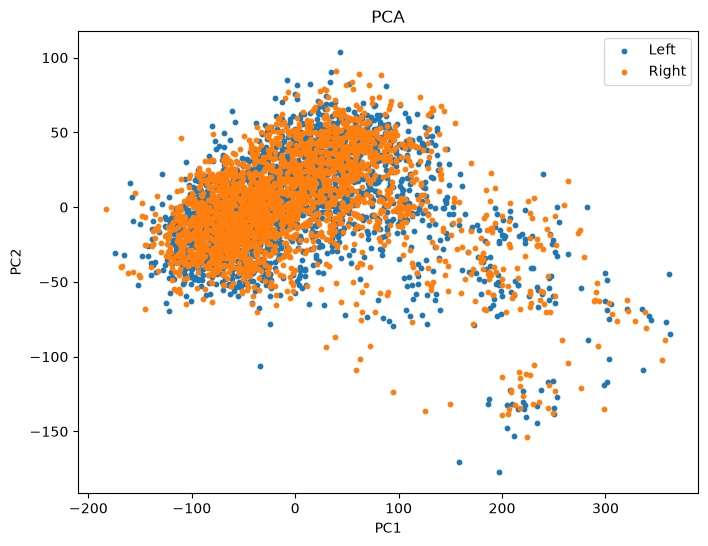

In [4]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_flat)

plt.figure(figsize=(8,6))

plt.scatter(

    X_pca[y==0,0],
    X_pca[y==0,1],

    s=10,

    label="Left"

)

plt.scatter(

    X_pca[y==1,0],
    X_pca[y==1,1],

    s=10,

    label="Right"

)

plt.legend()

plt.title("PCA")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

In [5]:
tsne = TSNE(

    n_components=2,

    perplexity=30,

    random_state=42

)

X_tsne = tsne.fit_transform(X_flat)

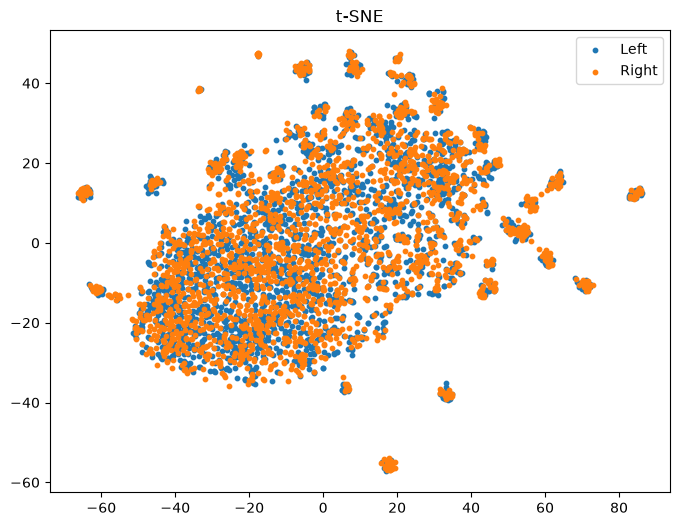

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(

    X_tsne[y==0,0],
    X_tsne[y==0,1],

    s=10,

    label="Left"

)

plt.scatter(

    X_tsne[y==1,0],
    X_tsne[y==1,1],

    s=10,

    label="Right"

)

plt.legend()

plt.title("t-SNE")

plt.show()

In [7]:
corr = np.corrcoef(

    X_flat.T

)

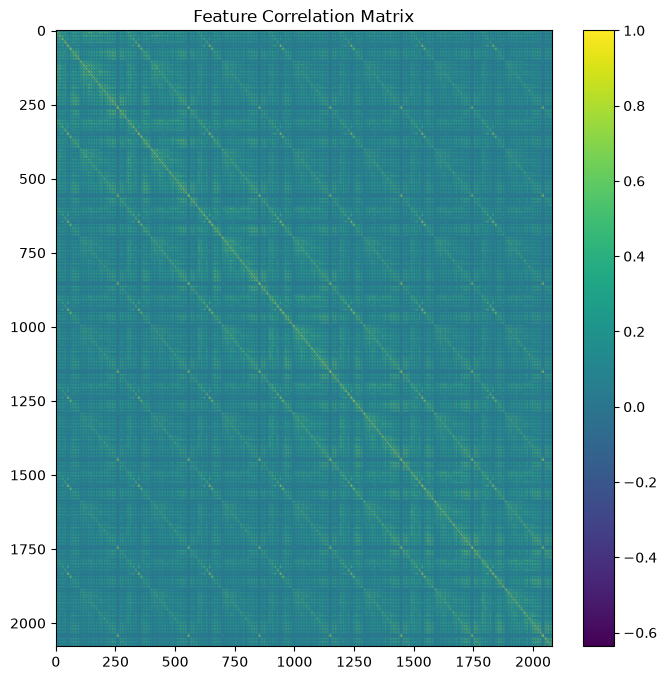

In [8]:
plt.figure(figsize=(8,8))

plt.imshow(

    corr,

    aspect="auto"

)

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.show()

In [9]:
left = X_flat[y==0]

right = X_flat[y==1]

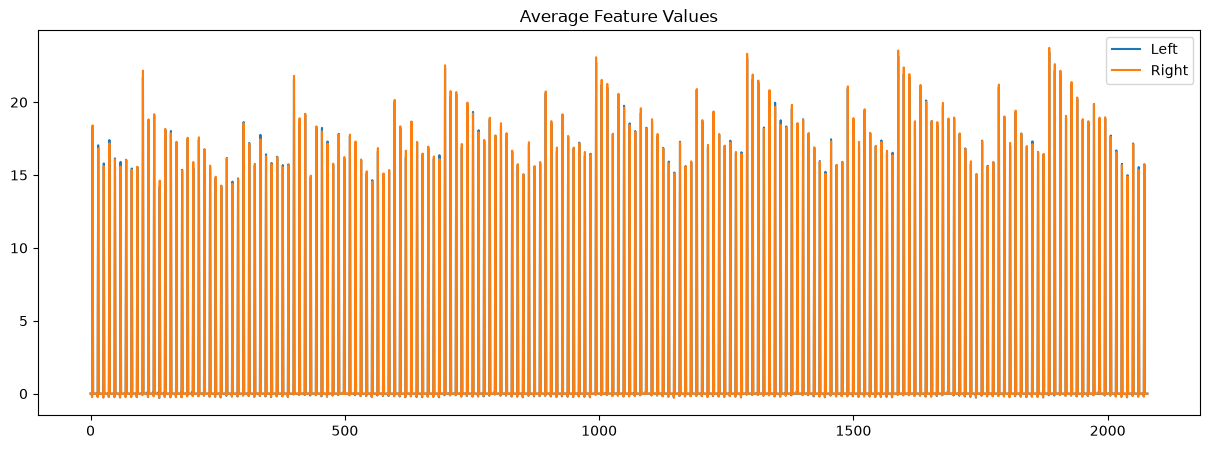

In [10]:
plt.figure(figsize=(15,5))

plt.plot(

    np.mean(left,axis=0),

    label="Left"

)

plt.plot(

    np.mean(right,axis=0),

    label="Right"

)

plt.legend()

plt.title("Average Feature Values")

plt.show()

In [11]:
window_energy = []

for i in range(7):

    energy = np.mean(

        np.abs(

            X[:,i,:]

        )

    )

    window_energy.append(energy)

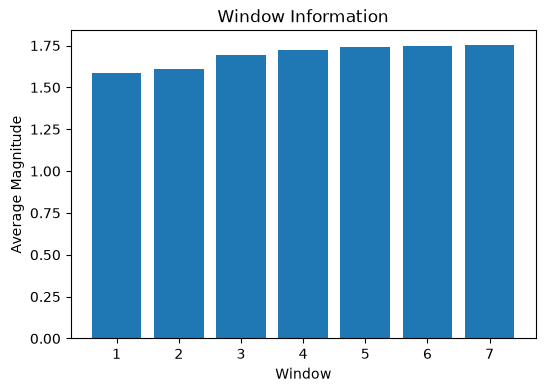

In [12]:
plt.figure(figsize=(6,4))

plt.bar(

    np.arange(1,8),

    window_energy

)

plt.xlabel("Window")

plt.ylabel("Average Magnitude")

plt.title("Window Information")

plt.show()

In [13]:
channel_energy = np.zeros(27)

for ch in range(27):

    idx = np.arange(

        ch*11,

        (ch+1)*11

    )

    channel_energy[ch] = np.mean(

        np.abs(

            X[:,:,idx]

        )

    )

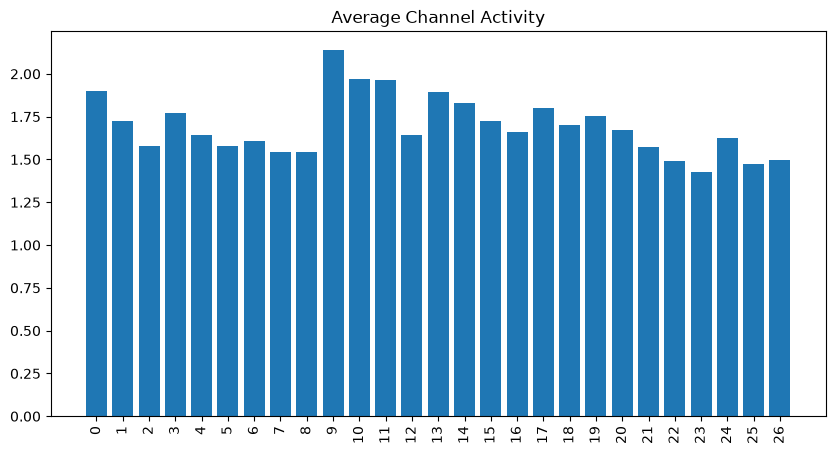

In [14]:
plt.figure(figsize=(10,5))

plt.bar(

    np.arange(27),

    channel_energy

)

plt.xticks(

    np.arange(27),

    rotation=90

)

plt.title("Average Channel Activity")

plt.show()

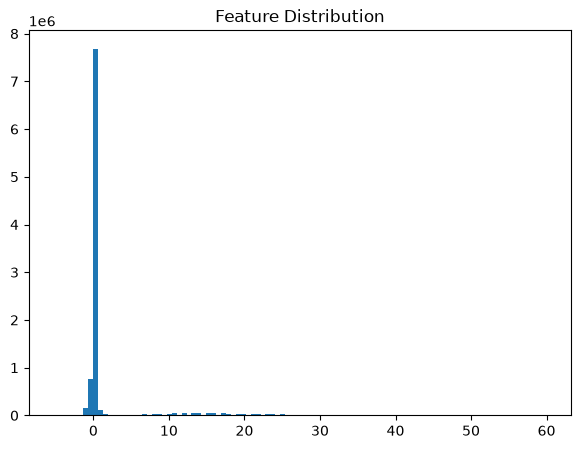

In [15]:
plt.figure(figsize=(7,5))

plt.hist(

    X_flat.ravel(),

    bins=100

)

plt.title("Feature Distribution")

plt.show()